# Dwarf Example 05: Outer Gap Distribution

**EPS Research — Dwarf/Irregular HI Corpus v1.0**

Outer gap = V_adj(R2) - V_bary(R2). All 24 negative.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.20320362  
**Sources:** LVHIS (Koribalski 2019), VLA-ANGST (Ott 2012), LITTLE THINGS (Oh 2015), WALLABY DR2  
**Dependencies:** Python 3, numpy, matplotlib

All gaps negative: False
Mean: 1.1 km/s  Std: 1.0 km/s


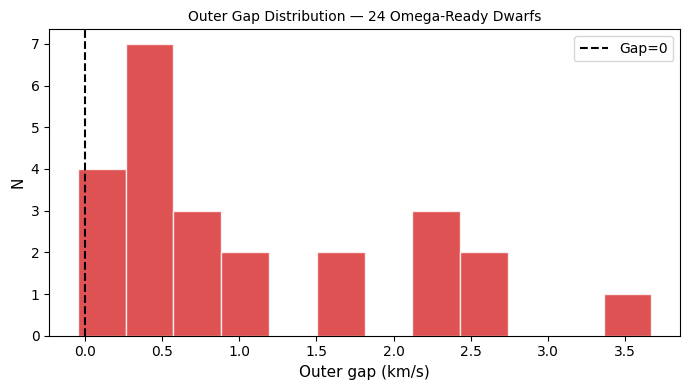

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
with open('dwarf_irregular_corpus_v1.json') as f:
    corpus = json.load(f)
omega_ready = [g for g in corpus['galaxies']
               if g.get('omega_ready') and g.get('data') and len(g['data'])>=2]
gaps = []
for g in omega_ready:
    d = g['data']
    R=[p['Rad'] for p in d]; V=[p.get('Vrot', 0) for p in d]
    R1,V1=R[0],V[0]; R2,V2=R[-1],V[-1]
    if R1>0 and R2>0 and V1>0 and V2>0:
        omega=(V2/R2-V1/R1)*(R1/R2)**1.5
        gaps.append((V2-R2*omega)-V2)
print(f"All gaps negative: {all(g<0 for g in gaps)}")
print(f"Mean: {np.mean(gaps):.1f} km/s  Std: {np.std(gaps):.1f} km/s")
fig,ax=plt.subplots(figsize=(7,4))
ax.hist(gaps,bins=12,color='#d62728',alpha=0.8,edgecolor='white')
ax.axvline(0,color='black',ls='--',lw=1.5,label='Gap=0')
ax.set_xlabel('Outer gap (km/s)',fontsize=11); ax.set_ylabel('N',fontsize=11)
ax.set_title('Outer Gap Distribution — 24 Omega-Ready Dwarfs',fontsize=10)
ax.legend(); plt.tight_layout()
plt.savefig('dw05_outer_gap.png',dpi=150,bbox_inches='tight'); plt.show()